In [2]:
import numpy as np

np.random.seed(42)

#parameters
n_samples = 2000
n_noise = int(0.15 * n_samples)  # 15% noise
n_clusters_samples = n_samples - n_noise

In [4]:
from sklearn.datasets import make_blobs

# create 4 clusters in 6D with varying densities
X_clusters, _ = make_blobs(
    n_samples = n_clusters_samples,
    centers = 4,
    n_features = 6,
    cluster_std = [0.4, 0.8, 1.2, 0.6],  # varying densities
    random_state = 42
)

In [5]:
# Add uniform noise
noise = np.random.uniform(
    low = X_clusters.min(axis=0),
    high = X_clusters.max(axis=0),
    size = (n_noise, 6)
)

In [6]:
# Final dataset
X = np.vstack([X_clusters, noise])

print("Dataset shape:", X.shape)
print("Noise ratio:", n_noise / n_samples)

Dataset shape: (2000, 6)
Noise ratio: 0.15


In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Mean:\n", np.mean(X_scaled, axis=0))
print("Std :\n", np.std(X_scaled, axis=0))

Mean:
 [ 2.96429548e-16  3.69815290e-16  3.02202707e-16  5.14699394e-16
 -3.53306273e-15  2.77555756e-17]
Std :
 [1. 1. 1. 1. 1. 1.]


> MinPts ≥ d+1, where d is dimensionality

In practice for noisy, varying-density data:
- MinPts≈2d to 3d

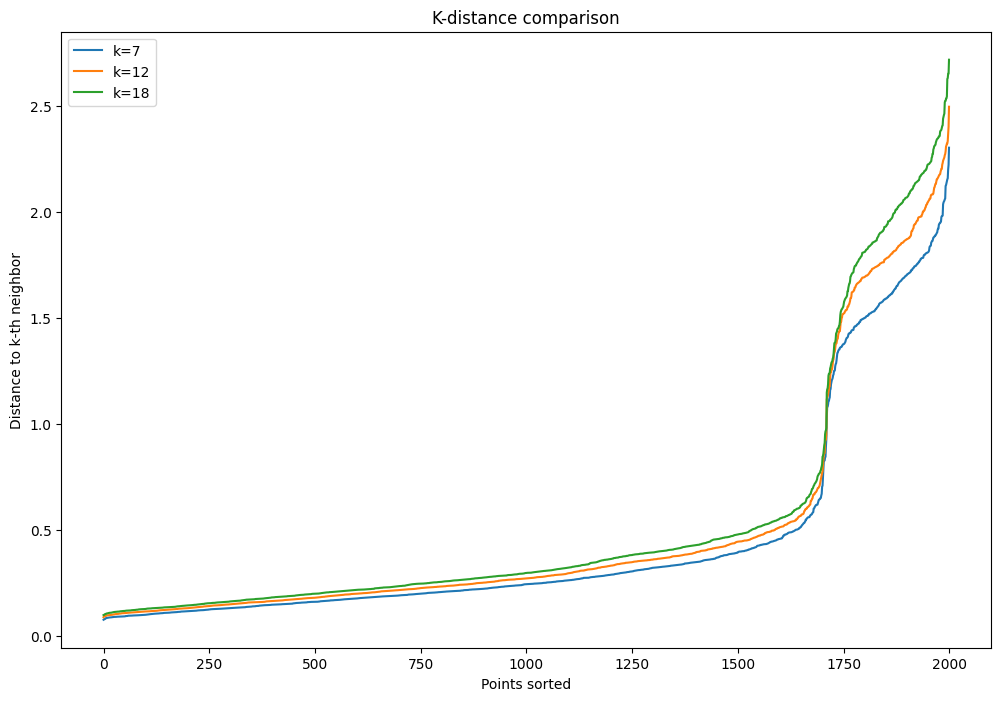

In [11]:
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt

minPts_values = [7, 12, 18]

plt.figure(figsize=(12, 8))

for k in minPts_values:
    neighbours = NearestNeighbors(n_neighbors=k)
    neighbours_fit = neighbours.fit(X_scaled)
    distances, _ = neighbours_fit.kneighbors(X_scaled)
    
    k_distances = np.sort(distances[:,-1])
    plt.plot(k_distances, label=f"k={k}")
    
plt.title("K-distance comparison")
plt.xlabel("Points sorted")
plt.ylabel("Distance to k-th neighbor")
plt.legend()
plt.show()      

- Look at where the curve sharply rises for k=12 (orange curve).

- From the plot, the knee appears around distance ≈ 0.75–0.85.

In [13]:
# recompute k = 12 distances
minPts = 12
neighbours = NearestNeighbors(n_neighbors=minPts)
neighbours_fit = neighbours.fit(X_scaled)
distances, _ = neighbours_fit.kneighbors(X_scaled)

k_distances = np.sort(distances[:,-1])

for p in range(75, 96, 5):
    value = np.percentile(k_distances, p)
    print(f"{p}th percentile: {value:.4f}")

75th percentile: 0.4457
80th percentile: 0.5141
85th percentile: 0.7711
90th percentile: 1.6930
95th percentile: 1.8710


**0.77 → 1.69 is a large jump.**
- ε ≈ 0.77

In [16]:
from sklearn.cluster import DBSCAN

eps = 0.77
minPts = 12

db = DBSCAN(eps=eps, min_samples=minPts)
labels = db.fit_predict(X_scaled)

unique_labels = np.unique(labels)

print("Unique labels:", unique_labels)
print("Number of clusters (excluding noise):", len(unique_labels[unique_labels != -1]))
print("Number of noise points:", np.sum(labels == -1))

Unique labels: [-1  0  1  2  3]
Number of clusters (excluding noise): 4
Number of noise points: 291


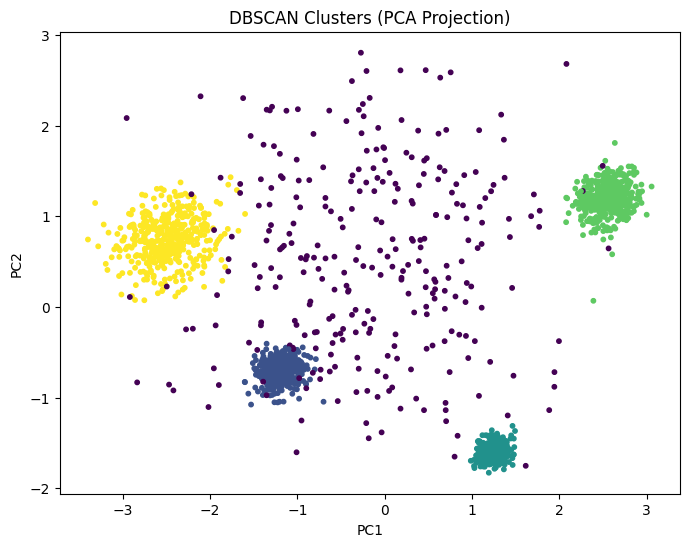

Explained variance ratio: [0.59097717 0.21438695]


In [17]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, s=10)
plt.title("DBSCAN Clusters (PCA Projection)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

print("Explained variance ratio:", pca.explained_variance_ratio_)